In [14]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import least_squares

import equations as eq

RESULTS = Path("results")
env = json.loads((RESULTS / "env.json").read_text())
data = pd.read_csv(RESULTS / "measurements.csv")

eq.BW_PEAK = env["bw_peak"]          # паспорт той карты, на которой мерили
eq.FLOPS_PEAK = env["flops_peak"]

ok = data[~data["oom"]]
train = ok[~ok["is_validation"]]
val = ok[ok["is_validation"]]


def error(predicted, measured):
    """Средняя относительная ошибка, %."""
    return float(np.abs(predicted / measured - 1).mean() * 100)


print(f"{len(data)} точек, из них OOM {data['oom'].sum()}")
print(f"обучение {len(train)}, валидация {len(val)}")


# FLOPs и Memory параметров не содержат — просто сверяем с измерениями
for name, df in ("обучение", train), ("валидация", val):
    predicted = eq.memory(df["S"].values, df["B"].values)
    print(f"memory, {name}: ошибка {error(predicted, df['memory'].values):.0f}%")

132 точек, из них OOM 0
обучение 63, валидация 69
memory, обучение: ошибка 28%
memory, валидация: ошибка 19%


In [16]:
for name, df in ("обучение", train), ("валидация", val):
    predicted = eq.memory(df["S"].values, df["B"].values)
    print(f"memory, {name}: ошибка {error(predicted, df['memory'].values):.0f}%")


# Латентность: theta0 и eta_compute
# eta_mem НЕ подбираем: сеть нигде не упирается в память, поэтому на невязку он
# не влияет и фит оставил бы его равным начальному приближению. Берём измеренный
# в ячейке 8 measure.py — как и P_idle, измеряем то, что можно измерить.
# Сверху eta_compute единицей не ограничиваем — выход за неё это диагностика:
# он означает, что cuDNN выполняет меньше операций, чем мы насчитали.
ETA_MEM = env["eta_mem"]


def latency_residuals(params, df):
    theta = {"theta0": params[0], "eta_mem": ETA_MEM, "eta_compute": params[1]}
    predicted = eq.latency(df["S"].values, df["B"].values, theta)
    return np.log(predicted) - np.log(df["latency"].values)


# Подгоняем два параметра:
# - theta0 (базовое время запуска, не зависит от S и B)
# - eta_compute (какую долю паспортной производительности выжимает сеть)
fit = least_squares(
    latency_residuals,                 # Как считаем ошибку
    x0=[train["latency"].min(), 0.3],  # Начальные значения параметров
    bounds=([1e-7, 1e-3], [1e-1, 3.0]),# В каких диапазонах ищем
    args=(train,),
)
theta = {"theta0": fit.x[0], "eta_mem": ETA_MEM, "eta_compute": fit.x[1]}

print(f"theta0      {theta['theta0'] * 1e6:6.0f} мкс")
print(f"eta_mem     {theta['eta_mem']:6.2f}  = {theta['eta_mem'] * eq.BW_PEAK / 1e9:5.0f} ГБ/с  (измерено)")
print(f"eta_compute {theta['eta_compute']:6.2f}  = {theta['eta_compute'] * eq.FLOPS_PEAK / 1e12:5.2f} ТФЛОП/с")

for name, df in ("обучение", train), ("валидация", val):
    predicted = eq.latency(df["S"].values, df["B"].values, theta)
    print(f"latency, {name}: ошибка {error(predicted, df['latency'].values):.0f}%")

# Какой член выигрывает max в каждой точке. Если memory не побеждает нигде, то
# eta_mem на невязку не влияла и осталась равной начальному приближению —
# это не откалиброванное значение, и в README так и надо написать.
times = pd.DataFrame({
    "launch": theta["theta0"],
    "memory": eq.bytes_moved(ok["S"].values, ok["B"].values) / (theta["eta_mem"] * eq.BW_PEAK),
    "compute": eq.flops(ok["S"].values, ok["B"].values) / (theta["eta_compute"] * eq.FLOPS_PEAK),
}, index=ok.index)
print("что ограничивает проход:")
print(times.idxmax(axis="columns").value_counts().to_string())

memory, обучение: ошибка 28%
memory, валидация: ошибка 19%
theta0         547 мкс
eta_mem       0.75  =   239 ГБ/с  (измерено)
eta_compute   0.36  =  2.91 ТФЛОП/с
latency, обучение: ошибка 19%
latency, валидация: ошибка 21%
что ограничивает проход:
compute    109
launch      23


In [17]:
env

{'gpu': 'Tesla T4',
 'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'cudnn': 91900,
 'total_memory': 15637086208,
 'bw_peak': 320000000000.0,
 'flops_peak': 8100000000000.0,
 'tdp': 70.0,
 'p_idle': 29.764256712496547,
 'bw_achieved': 238645191760.89844,
 'eta_mem': 0.7457662242528076}

In [18]:
# Энергия: e_flop и e_byte при измеренной P_idle и фиксированной theta
assert data["energy"].notna().any(), "энергия не измерялась, NVML был недоступен"
P_IDLE = env["p_idle"]


def energy_residuals(params, df):
    theta_energy = {**theta, "p_idle": P_IDLE, "e_flop": params[0], "e_byte": params[1]}
    predicted = eq.energy(df["S"].values, df["B"].values, theta_energy)
    return np.log(predicted) - np.log(df["energy"].values)


# Верхние границы из бюджета мощности: динамическая часть не может стоить больше,
# чем TDP минус простой. Делить бюджет надо на РЕАЛЬНО достигнутые скорости, а не
# на паспортные: карта не выходит на 8.1 ТФЛОП/с, поэтому граница из пикового
# значения оказывается в разы жёстче физической, и фит упирается в неё.
budget = env["tdp"] - P_IDLE
peak_flops = (eq.flops(ok["S"].values, ok["B"].values) / ok["latency"].values).max()
peak_bytes = (eq.bytes_moved(ok["S"].values, ok["B"].values) / ok["latency"].values).max()

# Подгоняем параметры по энергии
fit_energy = least_squares(
    energy_residuals,
    x0=[3e-12, 5e-11],
    bounds=([0.0, 0.0], [budget / peak_flops, budget / peak_bytes]),
    args=(train,),
)
theta_energy = {"p_idle": P_IDLE, "e_flop": fit_energy.x[0], "e_byte": fit_energy.x[1]}

print(f"p_idle {P_IDLE:.1f} Вт (измерено, не подбиралось)")
print(f"e_flop {theta_energy['e_flop'] * 1e12:.2f} пДж/FLOP")
print(f"e_byte {theta_energy['e_byte'] * 1e12:.1f} пДж/байт")
print(f"отношение e_byte/e_flop: {theta_energy['e_byte'] / theta_energy['e_flop']:.0f}")

full = {**theta, **theta_energy}
for name, df in ("обучение", train), ("валидация", val):
    predicted = eq.energy(df["S"].values, df["B"].values, full)
    print(f"energy, {name}: ошибка {error(predicted, df['energy'].values):.0f}%")

power = eq.energy(ok["S"].values, ok["B"].values, full) / eq.latency(ok["S"].values, ok["B"].values, theta)
print(f"предсказанная мощность {power.min():.0f}..{power.max():.0f} Вт при TDP {env['tdp']:.0f}")

p_idle 29.8 Вт (измерено, не подбиралось)
e_flop 3.11 пДж/FLOP
e_byte 881.1 пДж/байт
отношение e_byte/e_flop: 283
energy, обучение: ошибка 20%
energy, валидация: ошибка 21%
предсказанная мощность 37..74 Вт при TDP 70


In [19]:
(RESULTS / "theta.json").write_text(json.dumps({
    "env": env,
    "theta": theta,
    "theta_energy": theta_energy,
}, indent=2, ensure_ascii=False))
print("записано в", RESULTS / "theta.json")


записано в results/theta.json


In [20]:
import matplotlib.pyplot as plt

FIGURES = RESULTS / "figures"
FIGURES.mkdir(exist_ok=True)

# Четыре размера картинки, чтобы кривые не сливались в кашу
PLOT_SIZES = [64, 128, 256, 512]
COLORS = ["b", "g", "r", "m"]

# Батч, на котором cuDNN переключает conv1 с GEMM на FFT (видно в kernels.csv)
FFT_SWITCH = 111


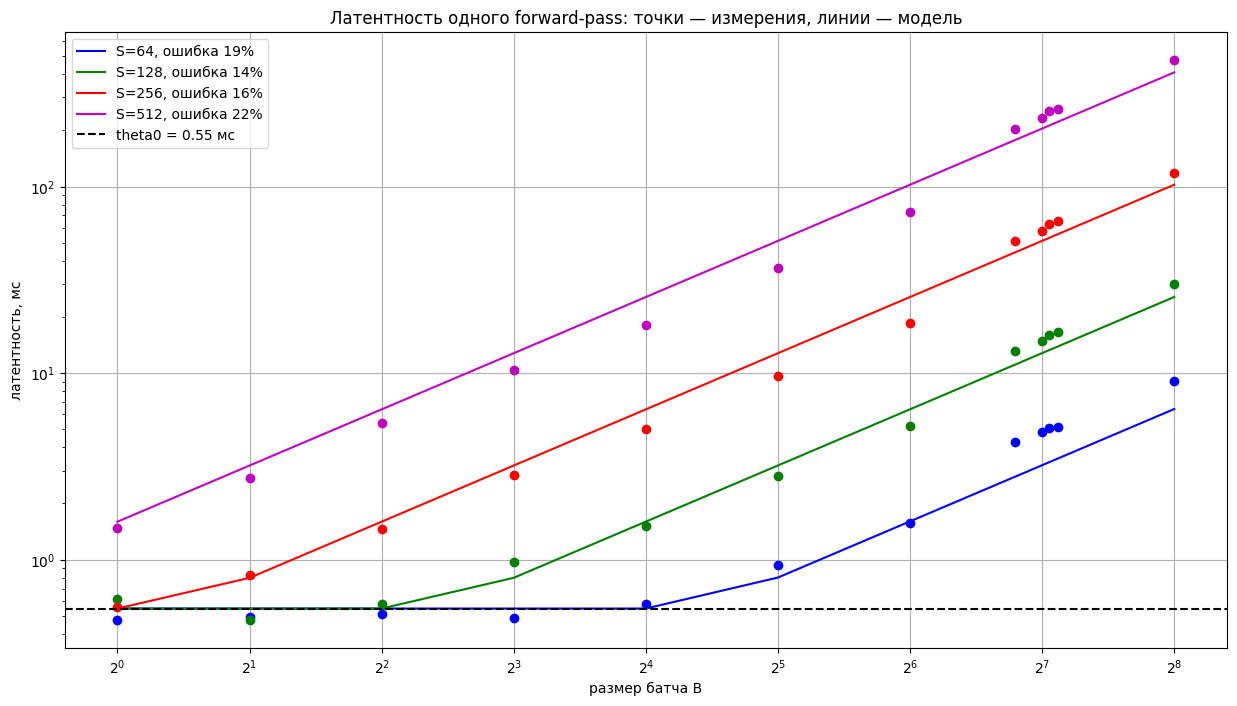

In [21]:
# Латентность: измерения против модели
plt.figure(figsize=(15, 8))
plt.title("Латентность одного forward-pass: точки — измерения, линии — модель")

for image_size, color in zip(PLOT_SIZES, COLORS):
    points = ok[ok["S"] == image_size].sort_values("B")
    predicted = eq.latency(points["S"].values, points["B"].values, theta)
    mean_error = round(error(predicted, points["latency"].values))
    plt.plot(points["B"], points["latency"] * 1e3, "o", color=color)
    plt.plot(points["B"], predicted * 1e3, "-", color=color,
             label=f"S={image_size}, ошибка {mean_error}%")

# Полка: ниже theta0 модель не опускается ни при каком размере задачи
plt.axhline(theta["theta0"] * 1e3, color="k", linestyle="--",
            label=f"theta0 = {round(theta['theta0'] * 1e3, 2)} мс")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("размер батча B")
plt.ylabel("латентность, мс")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "latency.png", dpi=120, bbox_inches="tight")
plt.show()

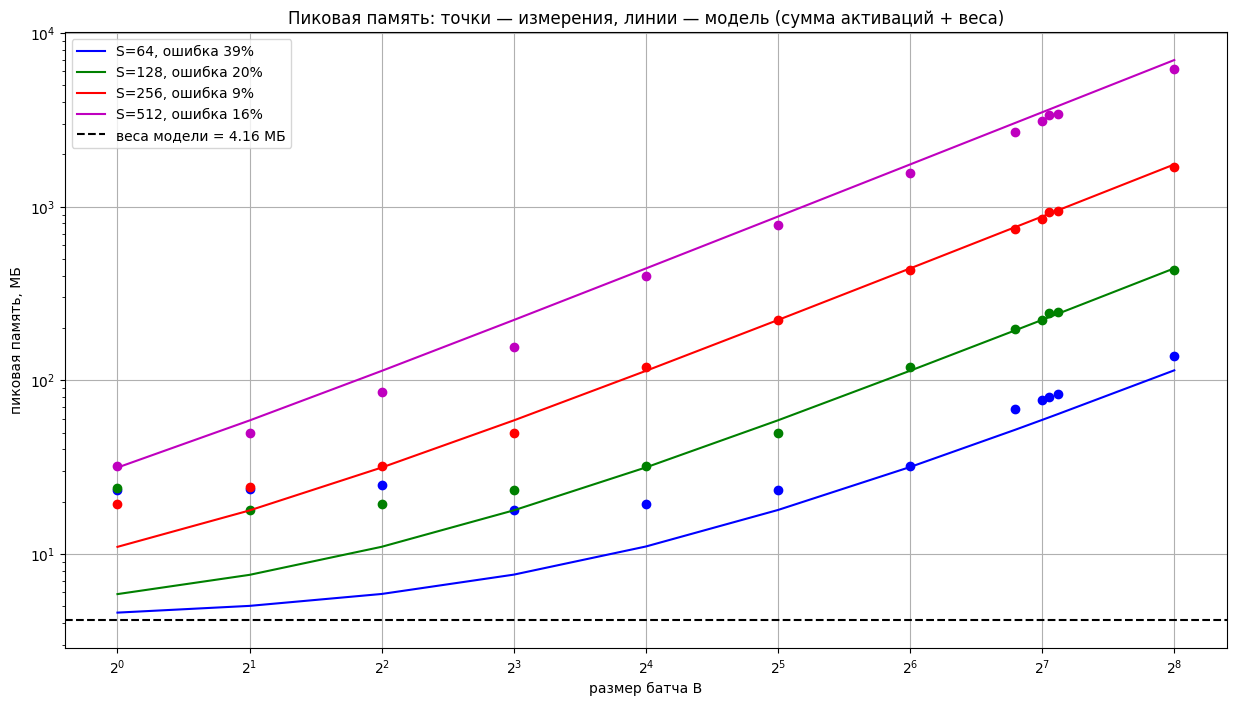

In [22]:
# Память: измерения против модели
plt.figure(figsize=(15, 8))
plt.title("Пиковая память: точки — измерения, линии — модель (сумма активаций + веса)")

for image_size, color in zip(PLOT_SIZES, COLORS):
    points = ok[ok["S"] == image_size].sort_values("B")
    predicted = eq.memory(points["S"].values, points["B"].values)
    mean_error = round(error(predicted, points["memory"].values))
    plt.plot(points["B"], points["memory"] / 1e6, "o", color=color)
    plt.plot(points["B"], predicted / 1e6, "-", color=color,
             label=f"S={image_size}, ошибка {mean_error}%")

# Веса живут в памяти всегда и не зависят от B — это нижняя граница
plt.axhline(eq.PARAMS_BYTES / 1e6, color="k", linestyle="--",
            label=f"веса модели = {round(eq.PARAMS_BYTES / 1e6, 2)} МБ")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("размер батча B")
plt.ylabel("пиковая память, МБ")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "memory.png", dpi=120, bbox_inches="tight")
plt.show()


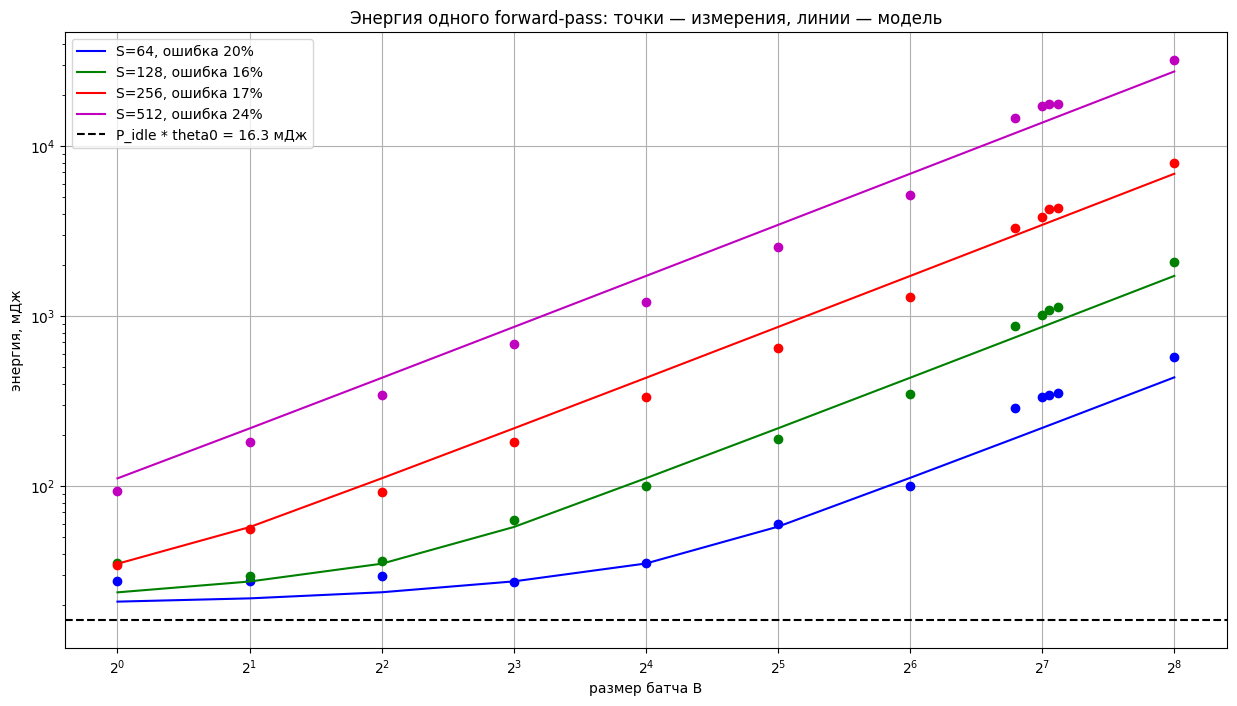

In [24]:
# Энергия: измерения против модели
plt.figure(figsize=(15, 8))
plt.title("Энергия одного forward-pass: точки — измерения, линии — модель")

for image_size, color in zip(PLOT_SIZES, COLORS):
    points = ok[ok["S"] == image_size].sort_values("B")
    predicted = eq.energy(points["S"].values, points["B"].values, full)
    mean_error = round(error(predicted, points["energy"].values))
    plt.plot(points["B"], points["energy"] * 1e3, "o", color=color)
    plt.plot(points["B"], predicted * 1e3, "-", color=color,
             label=f"S={image_size}, ошибка {mean_error}%")

# На полке карта простаивает, но потребляет: энергия упирается в P_idle * theta0
plt.axhline(theta_energy["p_idle"] * theta["theta0"] * 1e3, color="k", linestyle="--",
            label=f"P_idle * theta0 = {round(theta_energy['p_idle'] * theta['theta0'] * 1e3, 1)} мДж")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("размер батча B")
plt.ylabel("энергия, мДж")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "energy.png", dpi=120, bbox_inches="tight")
plt.show()

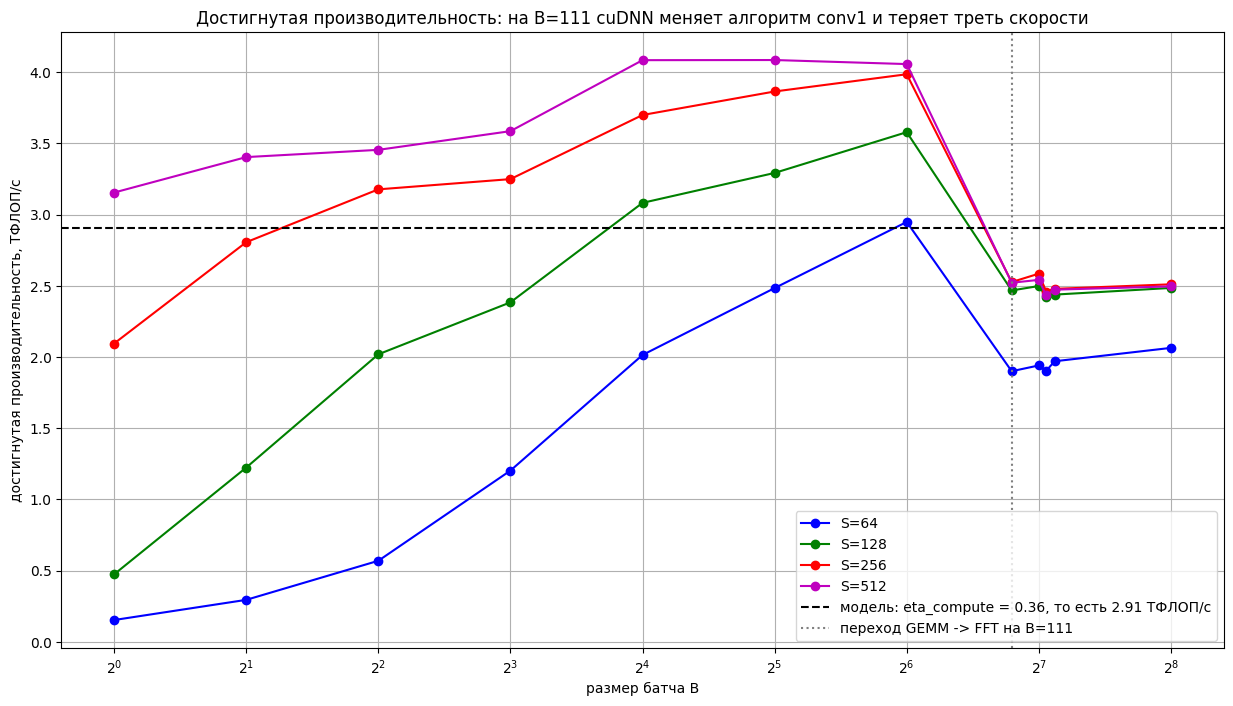

In [25]:
# Достигнутая производительность и обрыв на смене алгоритма
plt.figure(figsize=(15, 8))
plt.title("Достигнутая производительность: на B=111 cuDNN меняет алгоритм conv1 и теряет треть скорости")

for image_size, color in zip(PLOT_SIZES, COLORS):
    points = ok[ok["S"] == image_size].sort_values("B")
    tflops = eq.flops(points["S"].values, points["B"].values) / points["latency"].values / 1e12
    plt.plot(points["B"], tflops, "o-", color=color, label=f"S={image_size}")

# Модель знает одно число на всю сетку и вынуждена сесть между двумя режимами
model_tflops = theta["eta_compute"] * eq.FLOPS_PEAK / 1e12
plt.axhline(model_tflops, color="k", linestyle="--",
            label=f"модель: eta_compute = {round(theta['eta_compute'], 2)}, то есть {round(model_tflops, 2)} ТФЛОП/с")
plt.axvline(FFT_SWITCH, color="gray", linestyle=":", label=f"переход GEMM -> FFT на B={FFT_SWITCH}")

plt.xscale("log", base=2)
plt.xlabel("размер батча B")
plt.ylabel("достигнутая производительность, ТФЛОП/с")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "throughput.png", dpi=120, bbox_inches="tight")
plt.show()

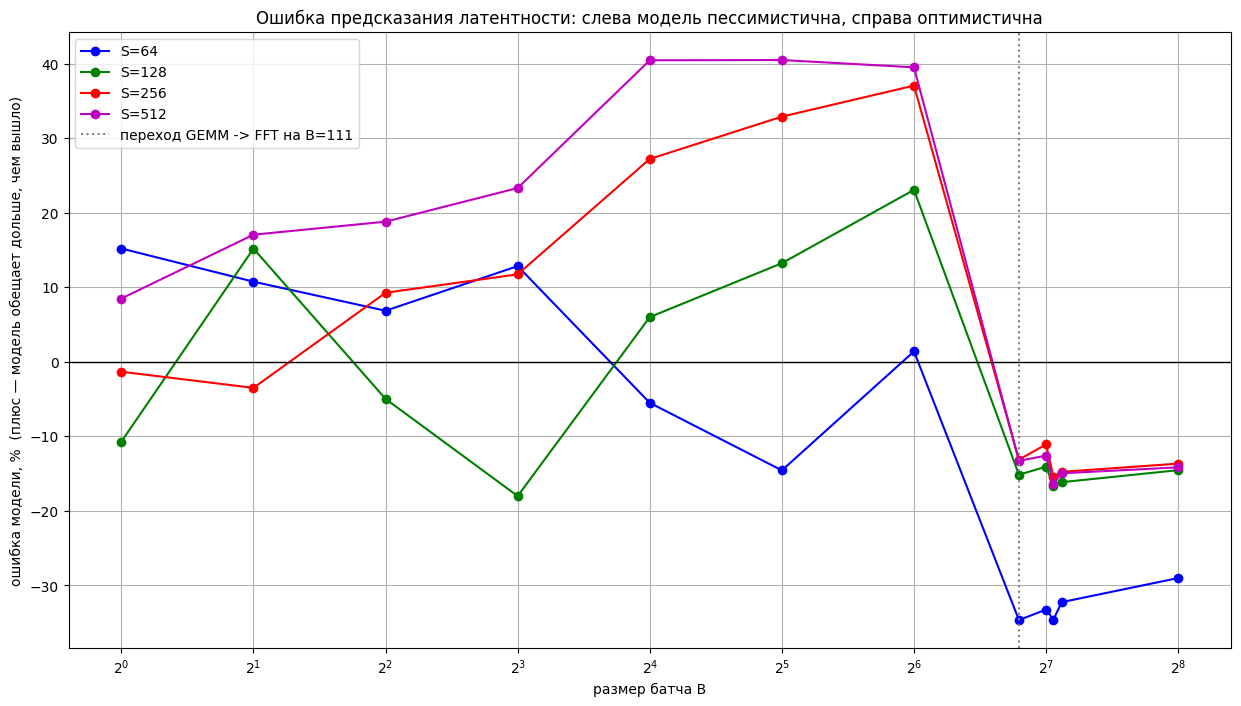

In [26]:
# Ошибка модели меняет знак ровно на смене алгоритма
plt.figure(figsize=(15, 8))
plt.title("Ошибка предсказания латентности: слева модель пессимистична, справа оптимистична")

for image_size, color in zip(PLOT_SIZES, COLORS):
    points = ok[ok["S"] == image_size].sort_values("B")
    predicted = eq.latency(points["S"].values, points["B"].values, theta)
    relative = (predicted / points["latency"].values - 1) * 100
    plt.plot(points["B"], relative, "o-", color=color, label=f"S={image_size}")

plt.axhline(0, color="k", linewidth=1)
plt.axvline(FFT_SWITCH, color="gray", linestyle=":", label=f"переход GEMM -> FFT на B={FFT_SWITCH}")

plt.xscale("log", base=2)
plt.xlabel("размер батча B")
plt.ylabel("ошибка модели, %  (плюс — модель обещает дольше, чем вышло)")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "latency_error.png", dpi=120, bbox_inches="tight")
plt.show()

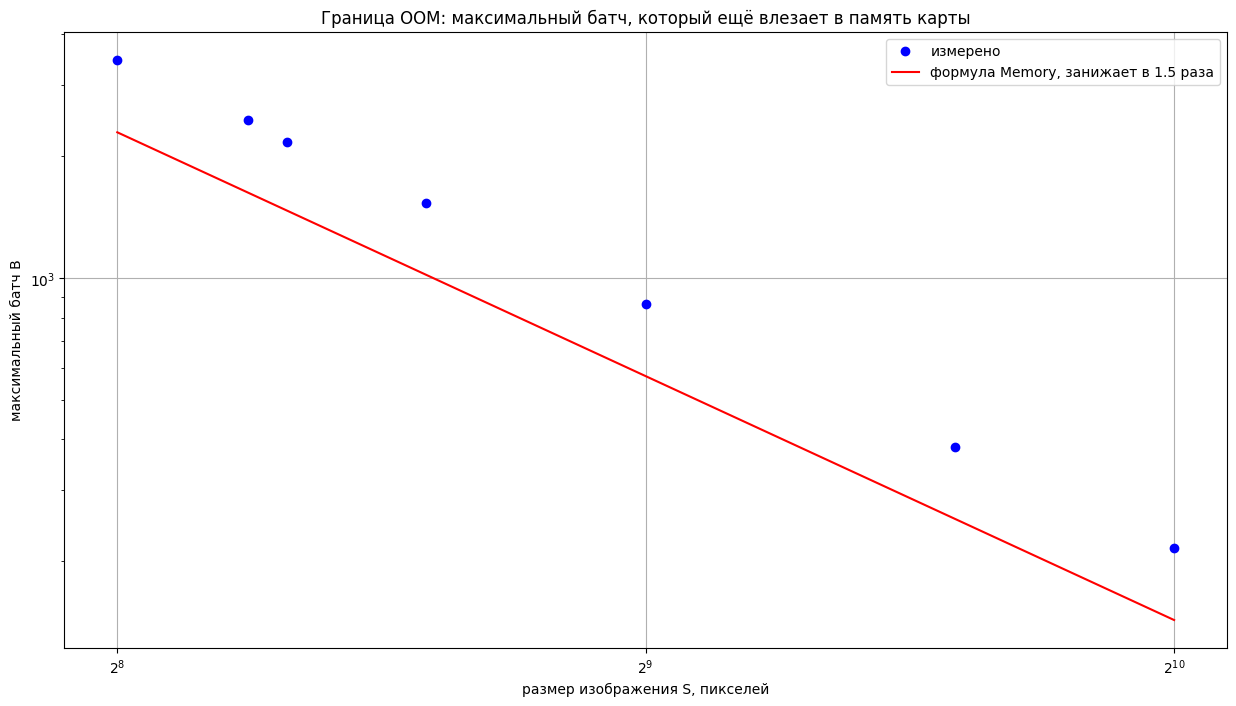

In [27]:
# Граница OOM: до какого батча конфигурация ещё помещается
plt.figure(figsize=(15, 8))
plt.title("Граница OOM: максимальный батч, который ещё влезает в память карты")

frontier = pd.read_csv(RESULTS / "oom_frontier.csv")
# Берём только размеры, где OOM реально наступил: на мелких S упёрлись в лимит перебора
found = frontier[frontier["b_min_oom"].notna()]
underestimate = round((found["b_max_fits"] / found["b_max_predicted"]).mean(), 2)

plt.plot(found["S"], found["b_max_fits"], "o", color="b", label="измерено")
plt.plot(found["S"], found["b_max_predicted"], "-", color="r",
         label=f"формула Memory, занижает в {underestimate} раза")

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("размер изображения S, пикселей")
plt.ylabel("максимальный батч B")
plt.grid()
plt.legend()
plt.savefig(FIGURES / "oom_frontier.png", dpi=120, bbox_inches="tight")
plt.show()